In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
data= pd.read_csv(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\datasets\Bank Customer Churn Prediction.csv")
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
data.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [5]:
encoder= LabelEncoder()
data['country_e']= encoder.fit_transform(data['country'])
data['gender_e']= encoder.fit_transform(data['gender'])
data

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_e,gender_e
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,2,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,0
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0,0
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,1


In [6]:
data['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [7]:
x=data[['country_e','gender_e','age','tenure','balance','estimated_salary']]
y=data['churn']

In [8]:
x.describe()

,country_e,gender_e,age,tenure,balance,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.746300,0.545700,38.921800,5.012800,76485.889288,100090.239881
std,0.827529,0.497932,10.487806,2.892174,62397.405202,57510.492818
min,0.000000,0.000000,18.000000,0.000000,0.000000,11.580000
25%,0.000000,0.000000,32.000000,3.000000,0.000000,51002.110000
50%,0.000000,1.000000,37.000000,5.000000,97198.540000,100193.915000
75%,1.000000,1.000000,44.000000,7.000000,127644.240000,149388.247500
max,2.000000,1.000000,92.000000,10.000000,250898.090000,199992.480000


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.30,random_state=40, stratify=y)

In [11]:
model= RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, n_estimators=200)

In [12]:
y_pred= model.predict(x_test)

In [13]:
model.score(x_train,y_train)

0.8795714285714286

In [14]:
model.score(x_test,y_test)

0.8166666666666667

In [15]:
accuracy_score(y_test, y_pred)

0.8166666666666667

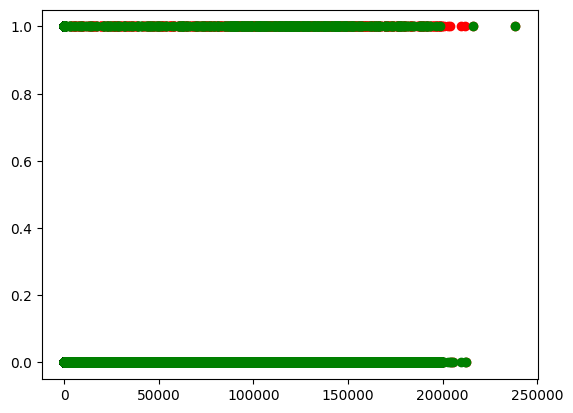

In [16]:
plt.plot(x_test, y_test,'ro')
plt.plot(x_test, y_pred,'go')

[[2274  115]
 [ 435  176]]


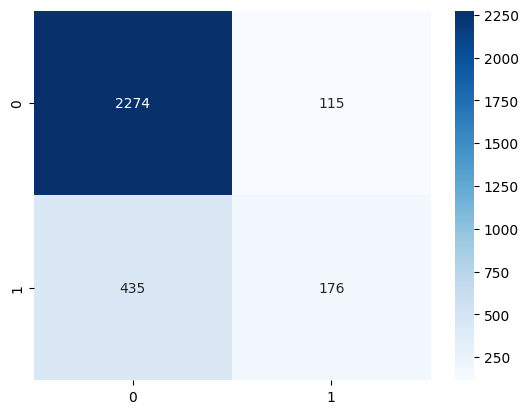

In [19]:
cm= confusion_matrix(y_test,y_pred)
sns.heatmap(data=cm, annot=True,fmt='d',cmap="Blues")
print(cm)

In [ ]:
print("\n", classification_report(y_test,y_pred))


               precision    recall  f1-score   support

           0       0.84      0.95      0.89      2389
           1       0.58      0.27      0.37       611

    accuracy                           0.81      3000
   macro avg       0.71      0.61      0.63      3000
weighted avg       0.78      0.81      0.78      3000



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(x_train, y_train)
print(grid.best_params_)



{'max_depth': 10, 'n_estimators': 100}


XGBOOSTING

In [ ]:
import xgboost
from xgboost import XGBClassifier

In [ ]:
model2= XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model2.fit(x_train, y_train)

c:\Users\PRATHEEK POOJARY\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:12:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_xgb= model2.predict(x_test)

In [ ]:
accuracy_score(y_test,y_xgb)

0.7926666666666666

In [ ]:
model2.score(x_test,y_test)

0.7926666666666666